In [10]:
import os
import json
import pickle
import pandas as pd
import mlflow
import joblib
from mlflow.tracking import MlflowClient

# =========================================================
# 0) Connexion MLflow
# =========================================================
TRACKING_URI = "http://127.0.0.1:5000"
EXP_NAME = "Multivariate_ML_Experimentation"
DL_DIR = "mlflow_import"

os.makedirs(DL_DIR, exist_ok=True)

mlflow.set_tracking_uri(TRACKING_URI)
client = MlflowClient()

exp = mlflow.get_experiment_by_name(EXP_NAME)
if exp is None:
    raise ValueError(f"Experiment introuvable: {EXP_NAME}")

runs = mlflow.search_runs([exp.experiment_id], output_format="pandas")
if runs.empty:
    raise ValueError("Aucun run trouvé.")

runs = runs.sort_values("start_time", ascending=False).reset_index(drop=True)
print("✅ runs:", len(runs))

# =========================================================
# Helpers
# =========================================================
def list_artifacts_recursive(run_id: str, path: str = ""):
    out = []
    stack = [path]
    while stack:
        p = stack.pop()
        try:
            items = client.list_artifacts(run_id, p)
        except Exception:
            continue
        for a in items:
            out.append(a)
            if a.is_dir:
                stack.append(a.path)
    return out

def download(run_id: str, artifact_path: str):
    return client.download_artifacts(run_id, artifact_path, dst_path=DL_DIR)

def find_first(run_id: str, pred):
    for a in list_artifacts_recursive(run_id):
        if a.is_dir:
            continue
        if pred(a):
            return a.path
    return None

def find_all(run_id: str, pred):
    paths = []
    for a in list_artifacts_recursive(run_id):
        if a.is_dir:
            continue
        if pred(a):
            paths.append(a.path)
    return paths

def _load_json(local_path: str):
    with open(local_path, "r", encoding="utf-8") as f:
        return json.load(f)

# =========================================================
# 1) Dernier run par (model_label, partition)
# =========================================================
runs["model_label"] = runs["tags.model_label"] if "tags.model_label" in runs.columns else None
runs["partition"]   = runs["tags.partition"] if "tags.partition" in runs.columns else None

runs_ok = runs.dropna(subset=["model_label", "partition"]).copy()
runs_ok["model_label"] = runs_ok["model_label"].astype(str)
runs_ok["partition"]   = runs_ok["partition"].astype(str)

runs_latest = (
    runs_ok.sort_values("start_time", ascending=False)
           .drop_duplicates(subset=["model_label", "partition"], keep="first")
           .reset_index(drop=True)
)

print("✅ unique (model,partition) runs:", len(runs_latest))

# =========================================================
# 2) Tables globales
# =========================================================
score_df_exp = None
leaderboard_exp = None

for _, r in runs_latest.iterrows():
    rid = r["run_id"]

    if score_df_exp is None:
        p = find_first(rid, lambda a: os.path.basename(a.path) == "score_df_exp.csv")
        if p:
            score_df_exp = pd.read_csv(download(rid, p))
            print("✅ score_df_exp loaded:", score_df_exp.shape, "|", p)

    if leaderboard_exp is None:
        p = find_first(rid, lambda a: os.path.basename(a.path) == "leaderboard_exp.csv")
        if p:
            leaderboard_exp = pd.read_csv(download(rid, p))
            print("✅ leaderboard_exp loaded:", leaderboard_exp.shape, "|", p)

    if score_df_exp is not None and leaderboard_exp is not None:
        break

# =========================================================
# 3) Explainability PAR PARTITION
# =========================================================
results_perm_mae_by_part = {}
results_perm_dev_by_part = {}
results_shap_share_by_part = {}

def collect_explainability(run_id: str):
    for a in list_artifacts_recursive(run_id):
        if a.is_dir or not a.path.endswith(".csv"):
            continue

        base = os.path.basename(a.path)

        if base.startswith("perm_mae_"):
            name = base.replace("perm_mae_", "").replace(".csv", "")
            if "_" in name:
                model_label, partition = name.split("_", 1)
                df = pd.read_csv(download(run_id, a.path))
                results_perm_mae_by_part.setdefault(partition, {})[model_label] = df

        elif base.startswith("perm_dev_"):
            name = base.replace("perm_dev_", "").replace(".csv", "")
            if "_" in name:
                model_label, partition = name.split("_", 1)
                df = pd.read_csv(download(run_id, a.path))
                results_perm_dev_by_part.setdefault(partition, {})[model_label] = df

        elif base.startswith("shap_"):
            name = base.replace("shap_", "").replace(".csv", "")
            if "_" in name:
                model_label, partition = name.split("_", 1)
                df = pd.read_csv(download(run_id, a.path))
                results_shap_share_by_part.setdefault(partition, {})[model_label] = df

for _, r in runs_latest.iterrows():
    collect_explainability(r["run_id"])

print("✅ partitions perm_mae:", sorted(results_perm_mae_by_part.keys()))
print("✅ partitions perm_dev:", sorted(results_perm_dev_by_part.keys()))
print("✅ partitions shap:", sorted(results_shap_share_by_part.keys()))

# =========================================================
# 4) bkt parquet par (model, partition)
# =========================================================
bkt_by_run = {}

for _, r in runs_latest.iterrows():
    model_label = str(r["model_label"])
    partition   = str(r["partition"])
    run_id      = r["run_id"]

    fname = f"bkt_{model_label}_{partition}.parquet"
    p = find_first(run_id, lambda a: os.path.basename(a.path) == fname)
    if p:
        local = download(run_id, p)
        bkt_by_run[(model_label, partition)] = pd.read_parquet(local)

print("✅ bkt parquet loaded:", len(bkt_by_run))

# =========================================================
# 4bis) X parquet + features json
# =========================================================
X_by_run = {}
features_by_run = {}

def _parse_model_partition_from_filename(base: str):
    if base.startswith("X_") and base.endswith(".parquet"):
        name = base.replace("X_", "").replace(".parquet", "")
    elif base.startswith("features_") and base.endswith(".json"):
        name = base.replace("features_", "").replace(".json", "")
    else:
        return None

    if "_" not in name:
        return None

    model_label, partition = name.split("_", 1)
    return model_label, partition

def collect_functional_data(run_id: str):
    x_paths = find_all(
        run_id,
        lambda a: (
            (a.path.startswith("functional/") or a.path.startswith("X/") or "/X_" in a.path)
            and os.path.basename(a.path).startswith("X_")
            and a.path.endswith(".parquet")
        )
    )

    for p in x_paths:
        base = os.path.basename(p)
        mp = _parse_model_partition_from_filename(base)
        if mp is None:
            continue
        model_label, partition = mp
        local = download(run_id, p)
        X_by_run[(model_label, partition)] = pd.read_parquet(local)

    f_paths = find_all(
        run_id,
        lambda a: (
            (a.path.startswith("functional/") or a.path.startswith("X/") or "/features_" in a.path)
            and os.path.basename(a.path).startswith("features_")
            and a.path.endswith(".json")
        )
    )

    for p in f_paths:
        base = os.path.basename(p)
        mp = _parse_model_partition_from_filename(base)
        if mp is None:
            continue
        model_label, partition = mp
        local = download(run_id, p)
        j = _load_json(local)

        if isinstance(j, list):
            feats = j
        elif isinstance(j, dict):
            feats = j.get("features", [])
        else:
            feats = []

        if isinstance(feats, list):
            features_by_run[(model_label, partition)] = feats

for _, r in runs_latest.iterrows():
    collect_functional_data(r["run_id"])

print("✅ X parquet loaded:", len(X_by_run))
print("✅ features json loaded:", len(features_by_run))
if X_by_run:
    k0 = list(X_by_run.keys())[0]
    print("Example X:", k0, X_by_run[k0].shape)

# =========================================================
# 4ter) preproc pickle
# =========================================================
preprocs_by_run = {}

def collect_preproc_data(run_id: str):
    p_paths = find_all(
        run_id,
        lambda a: (
            os.path.basename(a.path).startswith("preproc_")
            and a.path.endswith(".pkl")
        )
    )

    for p in p_paths:
        base = os.path.basename(p)
        name = base.replace("preproc_", "").replace(".pkl", "")
        if "_" not in name:
            continue

        model_label, partition = name.split("_", 1)

        try:
            local = download(run_id, p)
            with open(local, "rb") as f:
                preprocs_by_run[(model_label, partition)] = pickle.load(f)
        except Exception:
            pass

for _, r in runs_latest.iterrows():
    collect_preproc_data(r["run_id"])

print("✅ preproc loaded:", len(preprocs_by_run))

# =========================================================
# 5) Chargement des modèles
# =========================================================
models_mlflow = {}

def has_model_dir(run_id):
    try:
        return any(a.is_dir and a.path == "model" for a in client.list_artifacts(run_id, ""))
    except Exception:
        return False

def find_preferred_model_file(run_id, model_label, partition):
    p = find_first(run_id, lambda a: os.path.basename(a.path) == f"estimator_{model_label}_{partition}.joblib")
    if p:
        return p

    p = find_first(run_id, lambda a: os.path.basename(a.path) == f"model_{model_label}_{partition}.joblib")
    if p:
        return p

    p = find_first(run_id, lambda a: a.path.startswith("model/") and a.path.lower().endswith((".joblib", ".pkl")))
    if p:
        return p

    p = find_first(run_id, lambda a: a.path.lower().endswith((".joblib", ".pkl")))
    return p

for _, r in runs_latest.iterrows():
    model_label = str(r["model_label"])
    partition   = str(r["partition"])
    run_id      = r["run_id"]
    key = (model_label, partition)

    p = find_preferred_model_file(run_id, model_label, partition)
    if p:
        try:
            local = download(run_id, p)
            models_mlflow[key] = joblib.load(local)
            continue
        except Exception:
            pass

    if has_model_dir(run_id):
        try:
            models_mlflow[key] = mlflow.pyfunc.load_model(f"runs:/{run_id}/model")
            continue
        except Exception:
            pass

print("✅ loaded models:", len(models_mlflow))
print("Example keys:", list(models_mlflow.keys())[:5])

# =========================================================
# IMPORT SUMMARY
# =========================================================
print("\n================= IMPORT SUMMARY =================")
print("score_df_exp:", None if score_df_exp is None else score_df_exp.shape)
print("leaderboard_exp:", None if leaderboard_exp is None else leaderboard_exp.shape)
print("perm_mae partitions:", len(results_perm_mae_by_part))
print("perm_dev partitions:", len(results_perm_dev_by_part))
print("shap partitions:", len(results_shap_share_by_part))
print("bkt_by_run:", len(bkt_by_run))
print("X_by_run:", len(X_by_run))
print("features_by_run:", len(features_by_run))
print("preprocs_by_run:", len(preprocs_by_run))
print("models_mlflow:", len(models_mlflow))
print("==================================================")

# =========================================================
# (OPTIONNEL) Préparer directement les objets pour functional-grid
# =========================================================
def pick_key_for_model(model_label: str, prefer_partition="ALL"):
    keys = [k for k in X_by_run.keys() if k[0] == model_label]
    if not keys:
        return None

    if prefer_partition is not None:
        for k in keys:
            if k[1] == prefer_partition:
                return k

    for _, rr in runs_latest[runs_latest["model_label"] == model_label].iterrows():
        k = (model_label, str(rr["partition"]))
        if k in X_by_run:
            return k

    return keys[0]

label_map = {
    "LR": "Linear regression",
    "RIDGE": "Ridge regression",
    "LGBM": "LightGBM",
}

models_dict, X_dict, features_dict = {}, {}, {}

for ml in sorted(set(k[0] for k in X_by_run.keys())):
    key = pick_key_for_model(ml, prefer_partition="ALL")
    if key is None:
        continue
    if key not in models_mlflow:
        continue

    nice = label_map.get(ml, ml)
    prep = preprocs_by_run.get(key, None)

    models_dict[nice] = (models_mlflow[key], prep)
    X_dict[nice] = X_by_run[key]
    features_dict[nice] = features_by_run.get(key, [])

print("✅ models_dict ready:", list(models_dict.keys()))
print("✅ X_dict ready:", {k: v.shape for k, v in X_dict.items()})
print("✅ features_dict ready:", {k: len(v) for k, v in features_dict.items()})

✅ runs: 15
✅ unique (model,partition) runs: 15


✅ score_df_exp loaded: (15, 14) | tables/score_df_exp.csv


✅ leaderboard_exp loaded: (10, 14) | tables/leaderboard_exp.csv


✅ partitions perm_mae: ['1990-1999', '2000-2008', '2009-2019', '2020-end', 'ALL']
✅ partitions perm_dev: ['1990-1999', '2000-2008', '2009-2019', '2020-end', 'ALL']
✅ partitions shap: ['1990-1999', '2000-2008', '2009-2019', '2020-end', 'ALL']


✅ bkt parquet loaded: 15


✅ X parquet loaded: 15
✅ features json loaded: 15
Example X: ('RIDGE', 'ALL') (428, 11)
✅ preproc loaded: 0


✅ loaded models: 15
Example keys: [('RIDGE', 'ALL'), ('LR', 'ALL'), ('LGBM', 'ALL'), ('RIDGE', '2020-end'), ('RIDGE', '2009-2019')]

================= IMPORT SUMMARY =================
score_df_exp: (15, 14)
leaderboard_exp: (10, 14)
perm_mae partitions: 5
perm_dev partitions: 5
shap partitions: 5
bkt_by_run: 15
X_by_run: 15
features_by_run: 15
preprocs_by_run: 0
models_mlflow: 15
✅ models_dict ready: ['LightGBM', 'Linear regression', 'Ridge regression']
✅ X_dict ready: {'LightGBM': (428, 11), 'Linear regression': (428, 11), 'Ridge regression': (428, 11)}
✅ features_dict ready: {'LightGBM': 10, 'Linear regression': 10, 'Ridge regression': 10}


# Vérification

In [11]:
import numpy as np
import pandas as pd

# =========================
# 0) Sanity: objets existent ?
# =========================
print("models_mlflow:", len(models_mlflow))
print("X_by_run:", len(X_by_run))
print("models_dict:", list(models_dict.keys()))
print("X_dict:", {k: v.shape for k,v in X_dict.items()})

# =========================
# 1) Vérifier que LightGBM n'est PAS un MLForecast
# =========================
def unwrap(m):
    base = m
    if hasattr(base, "_base"):
        try: base = base._base
        except: pass
    return base

for name, (m, prep) in models_dict.items():
    base = unwrap(m)
    print("\n---", name, "---")
    print("type(model):", type(m))
    print("type(base): ", type(base))
    print("has predict:", hasattr(base, "predict"))
    print("has coef_:", hasattr(base, "coef_"))
    # détecter MLForecast
    print("looks like MLForecast:", "MLForecast" in str(type(base)))

# =========================
# 2) Vérifier X : index datetime + colonnes cohérentes
# =========================
for name, X in X_dict.items():
    print("\n--- X for", name, "---")
    print("shape:", X.shape)
    print("index type:", type(X.index))
    if not isinstance(X.index, pd.DatetimeIndex):
        print("❌ X.index n'est pas DatetimeIndex -> à corriger pour alignement temporel")
    else:
        print("dates:", X.index.min(), "->", X.index.max())
    print("n_nan_total:", int(X.isna().sum().sum()))
    print("head cols:", list(X.columns[:8]))

# =========================
# 3) Vérifier présence des variables requises (avec alias simples)
# =========================
selected_vars = ["UNRATE_lags_12", "INDPRO", "S&P500", "BUSLOANS", "TB3MS", "RPI"]

alias = {
    "UNRATE_lags_12": ["UNRATE_lag12", "UNRATE_LAG12", "UNRATE_lags12"],
    "S&P500": ["SP500", "S&P_500", "SP_500"],
    "BUSLOANS": ["BUSLOANS", "BUS_LOANS"],
    "INDPRO": ["INDPRO"],
    "TB3MS": ["TB3MS", "TB3M"],
    "RPI": ["RPI", "REAL_PI", "PI"],
}

def resolve(col_list, feat):
    if feat in col_list:
        return feat
    for a in alias.get(feat, []):
        if a in col_list:
            return a
    # fallback "contains"
    f = feat.replace("&","").replace(".","").replace(" ","").upper()
    for c in col_list:
        if f in str(c).replace("&","").replace(".","").replace(" ","").upper():
            return c
    return None

for name, X in X_dict.items():
    missing = []
    for v in selected_vars:
        if resolve(X.columns, v) is None:
            missing.append(v)
    print(f"\n{name} missing vars:", missing if missing else "✅ none")

# =========================
# 4) Diagnostic clé: est-ce que LightGBM est un estimator utilisable par SHAP TreeExplainer ?
# =========================
if "LightGBM" in models_dict:
    m = models_dict["LightGBM"][0]
    base = unwrap(m)

    # indicateurs LightGBM estimator
    lgbm_signals = {
        "has booster": hasattr(base, "booster_") or hasattr(base, "_Booster"),
        "has feature_name_": hasattr(base, "feature_name_"),
        "has n_features_": hasattr(base, "n_features_") or hasattr(base, "n_features_in_"),
    }
    print("\n[LightGBM signals]", lgbm_signals)

    if "MLForecast" in str(type(base)):
        print("❌ PROBLÈME: LightGBM = MLForecast wrapper -> SHAP TreeExplainer ne marchera pas.")
        print("✅ Il faut logger dans MLflow l'estimator interne (LGBMRegressor / Booster), pas l'objet MLForecast.")
    else:
        print("✅ OK: LightGBM n'est pas MLForecast wrapper (a priori).")

models_mlflow: 15
X_by_run: 15
models_dict: ['LightGBM', 'Linear regression', 'Ridge regression']
X_dict: {'LightGBM': (428, 11), 'Linear regression': (428, 11), 'Ridge regression': (428, 11)}

--- LightGBM ---
type(model): <class 'lightgbm.sklearn.LGBMRegressor'>
type(base):  <class 'lightgbm.sklearn.LGBMRegressor'>
has predict: True
has coef_: False
looks like MLForecast: False

--- Linear regression ---
type(model): <class 'sklearn.linear_model._base.LinearRegression'>
type(base):  <class 'sklearn.linear_model._base.LinearRegression'>
has predict: True
has coef_: True
looks like MLForecast: False

--- Ridge regression ---
type(model): <class 'sklearn.linear_model._ridge.Ridge'>
type(base):  <class 'sklearn.linear_model._ridge.Ridge'>
has predict: True
has coef_: True
looks like MLForecast: False

--- X for LightGBM ---
shape: (428, 11)
index type: <class 'pandas.core.indexes.range.RangeIndex'>
❌ X.index n'est pas DatetimeIndex -> à corriger pour alignement temporel
n_nan_total: 0
he

# Analye globale

# Appel

In [12]:
# ============================================================
# Functional-form plots — GRID (rows=variables, cols=models)
# + ✅ possibilité de filtrer par dates (start_date / end_date)
# + ✅ pretty labels via _pretty_label_from_feat
# + ✅ correction : plus besoin d'index commun entre modèles
# + ✅ correction : message clair si models_dict est vide
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# ---------------------- setup DARK THEME (global)
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor": "#0d0d0d",
    "axes.facecolor":   "#111111",
    "savefig.facecolor":"#0d0d0d",
    "text.color":       "#e5e5e5",
    "axes.edgecolor":   "#bfbfbf",
    "axes.labelcolor":  "#e5e5e5",
    "xtick.color":      "#d8d8d8",
    "ytick.color":      "#d8d8d8",
    "grid.color":       "#5a5a5a",
})
_DARK_LINE = "#ffffff"
_DARK_ZERO = "#7a5a5a"
_DARK_NA   = "#a5a5a5"
_DARK_GRID = (0.25, ":")

_DARK_COLORS = (
    "#7fdfff",
    "#ffd166",
    "#ff7f7f",
    "#9d7aff",
    "#8bd17c",
    "#f29ae1",
)

# ---------------------- unwrap / détection modèles
def _unwrap_model(m):
    base = m
    if hasattr(base, "_base"):
        try:
            base = base._base
        except Exception:
            pass
    try:
        from sklearn.pipeline import Pipeline
        if isinstance(base, Pipeline):
            base = base.steps[-1][1]
    except Exception:
        pass
    return base

def _name_blob(model) -> str:
    cls = type(model)
    return f"{cls.__name__}|{getattr(cls, '__module__', '')}".lower()

def _is_tree_model(model) -> bool:
    blob = _name_blob(model)
    keys = ("lgbm", "lightgbm", "xgboost", "catboost", "histgradient", "randomforest", "gradientboost")
    return any(k in blob for k in keys)

# ---------------------- préproc "safe"
def _apply_prep(X: pd.DataFrame, prep):
    if prep is None:
        return X
    if hasattr(prep, "transform"):
        Xp = prep.transform(X)
        try:
            return pd.DataFrame(Xp, index=X.index, columns=X.columns)
        except Exception:
            return pd.DataFrame(Xp, index=X.index)
    Xp = X.copy()
    if isinstance(prep, dict):
        lower = prep.get("lower_wins", prep.get("lower", None))
        upper = prep.get("upper_wins", prep.get("upper", None))
        if lower is not None and upper is not None:
            lo = pd.Series(lower, index=Xp.columns) if not isinstance(lower, pd.Series) else lower.reindex(Xp.columns)
            up = pd.Series(upper, index=Xp.columns) if not isinstance(upper, pd.Series) else upper.reindex(Xp.columns)
            Xp = Xp.clip(lower=lo, upper=up, axis=1)
        if prep.get("norm", False):
            mean = prep.get("mean", None)
            std  = prep.get("std",  None)
            if mean is not None and std is not None:
                mean_s = pd.Series(mean, index=Xp.columns) if not isinstance(mean, pd.Series) else mean.reindex(Xp.columns)
                std_s  = pd.Series(std,  index=Xp.columns) if not isinstance(std,  pd.Series) else std.reindex(Xp.columns)
                Xp = (Xp - mean_s) / std_s.replace(0, 1)
    return Xp

# ---------------------- LightGBM helpers
def _lgbm_feature_names(model) -> list | None:
    names = getattr(model, "feature_name_", None)
    if names:
        return list(names)
    booster = getattr(model, "_Booster", None)
    if booster is not None and hasattr(booster, "feature_name"):
        try:
            return list(booster.feature_name())
        except Exception:
            pass
    return None

def _reorder_X_for_lgbm(model, X: pd.DataFrame) -> pd.DataFrame:
    names = _lgbm_feature_names(model)
    if names:
        cols = [c for c in names if c in X.columns]
        if cols:
            return X.loc[:, cols]
    return X

# ---------------------- SHAP / contributions
def _compute_phi(model, X: pd.DataFrame, prep=None) -> np.ndarray:
    base = _unwrap_model(model)

    if _is_tree_model(base):
        Xp = _apply_prep(_reorder_X_for_lgbm(base, X), prep).astype(float)
        try:
            expl = shap.TreeExplainer(base, Xp, check_additivity=False)
            sv = expl.shap_values(Xp)
        except TypeError:
            expl = shap.TreeExplainer(base, Xp)
            sv = expl.shap_values(Xp, check_additivity=False)

        phi = sv[0] if isinstance(sv, list) else np.asarray(sv)
        if np.ndim(phi) == 3:
            phi = phi[0]
        if phi.shape[1] != Xp.shape[1]:
            raise ValueError("Dimensions SHAP incohérentes (arbres).")
        return np.asarray(phi)

    coef = getattr(base, "coef_", None)
    if coef is None:
        raise TypeError(f"Modèle non supporté (coef_ absent et non-arbre): {type(base)}")

    Xp = _apply_prep(X, prep).astype(float)
    mu = np.nanmean(Xp, axis=0)
    Xc = Xp - mu
    phi = Xc.to_numpy() * np.asarray(coef).reshape(1, -1)
    return phi

# ---------------------- Alias & résolution de noms
_alias_map = {
    "UNRATE_lags_12": ["UNRATE_lag12", "UNRATE_lags12", "lag12_UNRATE", "UNRATE_L12", "UNRATE_LAG_12", "UNRATE_LAG12"],
    "INDPRO":  ["INDPRO_lag12"],
    "BUSLOANS":["BUSLOANS_lag12"],
    "TB3MS":   ["TB3MS_lag12"],
    "RPI":     ["RPI_lag12"],
    "M2SL":    ["M2SL_lag12"],
    "OILPRICEX":["OILPRICEX_lag12"],
    "CPIAUCSL":["CPIAUCSL_lag12"],
    "DPCERA3M086SBEA":["DPCERA3M086SBEA_lag12"],
    "S&P500":  ["SP500_lag12", "SP500", "S_P_500", "SANDP500", "SP_500", "S&P_500"],
    "SP500":   ["SP500_lag12"],
}

def _resolve_feature_name(col_list, feat):
    if feat in col_list:
        return feat
    for alt in _alias_map.get(feat, []):
        if alt in col_list:
            return alt
    if f"{feat}_lag12" in col_list:
        return f"{feat}_lag12"
    f = re.sub(r"[^A-Z0-9]", "", str(feat).upper())
    for col in col_list:
        c = re.sub(r"[^A-Z0-9]", "", str(col).upper())
        if c == f:
            return col
    return None

# ---------------------- Date helpers
def _ensure_ms_ts(x):
    return pd.Timestamp(x).to_period("M").to_timestamp(how="start").normalize()

def _coerce_to_month_start_index(X: pd.DataFrame, date_col: str = "ds") -> pd.DataFrame:
    out = X.copy()

    if date_col in out.columns:
        ds = pd.to_datetime(out[date_col], errors="coerce")
        ds = ds.dt.to_period("M").dt.to_timestamp(how="start").dt.normalize()
        keep = ds.notna()
        out = out.loc[keep].copy()
        out[date_col] = ds.loc[keep]
        out = out.set_index(date_col)
        return out

    if isinstance(out.index, pd.DatetimeIndex):
        idx = pd.to_datetime(out.index, errors="coerce")
        keep = ~pd.isna(idx)
        out = out.loc[keep].copy()
        out.index = idx[keep].to_period("M").to_timestamp(how="start").normalize()
        return out

    try:
        idx = pd.to_datetime(out.index, errors="coerce")
        if not pd.isna(idx).all():
            keep = ~pd.isna(idx)
            out = out.loc[keep].copy()
            out.index = idx[keep].to_period("M").to_timestamp(how="start").normalize()
            return out
    except Exception:
        pass

    return out

def _filter_X_by_date(X: pd.DataFrame, start_date=None, end_date=None, date_col: str = "ds") -> pd.DataFrame:
    out = _coerce_to_month_start_index(X, date_col=date_col)

    if start_date is None and end_date is None:
        return out

    start = _ensure_ms_ts(start_date) if start_date is not None else None
    end   = _ensure_ms_ts(end_date)   if end_date is not None else None

    if isinstance(out.index, pd.DatetimeIndex):
        if start is not None:
            out = out.loc[out.index >= start]
        if end is not None:
            out = out.loc[out.index <= end]

    return out

# ---------------------- Pretty-label helper
def _pretty_feat_label(feat: str, pretty_map: dict | None):
    if not pretty_map:
        return feat
    return pretty_map.get(feat, feat)

# ---------------------- Tracé en grille
def plot_functional_grid(
    models_dict,
    X_dict,
    selected_vars,
    *,
    start_date: str | pd.Timestamp | None = None,
    end_date: str | pd.Timestamp | None = None,
    date_col: str = "ds",
    poly_deg_lgbm=3,
    scatter_alpha=0.70,
    s=18,
    colors=_DARK_COLORS,
    figsize_per_cell=(3.1, 2.7),
    sharey=False,
    max_n=2000,
    random_state=42,
    _pretty_label_from_feat: dict | None = None,
    use_pretty_labels: bool = True,
):
    model_names = list(models_dict.keys())

    if len(model_names) == 0:
        raise ValueError("models_dict est vide. Aucun modèle disponible pour tracer la grille.")

    if len(selected_vars) == 0:
        raise ValueError("selected_vars est vide. Aucune variable à tracer.")

    X_dict_f = {}
    for m in model_names:
        if m not in X_dict:
            raise KeyError(f"X_dict ne contient pas la clé modèle: {m}")
        Xi = _filter_X_by_date(
            X_dict[m],
            start_date=start_date,
            end_date=end_date,
            date_col=date_col,
        )
        if len(Xi) == 0:
            raise RuntimeError(f"Aucune donnée disponible pour le modèle '{m}' après filtre date.")
        X_dict_f[m] = Xi

    n_rows, n_cols = len(selected_vars), len(model_names)
    fig_w = max(6.0, n_cols * figsize_per_cell[0])
    fig_h = max(6.0, n_rows * figsize_per_cell[1])
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), sharey=sharey)
    fig.patch.set_facecolor("#0d0d0d")

    if n_rows == 1:
        axes = np.array([axes])
    if n_cols == 1:
        axes = axes.reshape(-1, 1)

    for c, (mname, (model, prep)) in enumerate(models_dict.items()):
        X_full_all = X_dict_f[mname].copy()

        if max_n is not None and len(X_full_all) > max_n:
            X_full_all = X_full_all.sample(max_n, random_state=random_state).sort_index()

        base = _unwrap_model(model)
        is_linear = (hasattr(base, "coef_") and not _is_tree_model(base))

        phi = np.asarray(_compute_phi(model, X_full_all, prep=prep))
        X_plot_all = _apply_prep(X_full_all, prep) if is_linear else X_full_all

        if isinstance(X_plot_all, pd.DataFrame):
            X_plot_all.columns = X_full_all.columns

        col_index_map = {col: j for j, col in enumerate(X_full_all.columns)}
        deg = 1 if is_linear else poly_deg_lgbm
        color_pts = colors[c % len(colors)]

        for r, feat in enumerate(selected_vars):
            ax = axes[r, c]
            ax.set_facecolor("#111111")

            resolved = _resolve_feature_name(X_full_all.columns, feat)
            ylab = _pretty_feat_label(feat, _pretty_label_from_feat) if use_pretty_labels else feat

            if resolved is None or resolved not in col_index_map:
                ax.text(
                    0.5, 0.5, "NA",
                    ha="center", va="center",
                    fontsize=11, fontweight="bold", color=_DARK_NA,
                    transform=ax.transAxes
                )
                ax.set_xticks([])
                ax.set_yticks([])
                for sp in ("top", "right"):
                    ax.spines[sp].set_visible(False)
                if r == 0:
                    ax.set_title(mname, fontsize=9, pad=4, color="#e5e5e5")
                if c == 0:
                    ax.set_ylabel(ylab, fontsize=9, color="#e5e5e5")
                continue

            j = col_index_map[resolved]
            x = X_plot_all.iloc[:, j].to_numpy()
            y = phi[:, j]

            mask = ~(np.isnan(x) | np.isnan(y))
            x, y = x[mask], y[mask]

            ax.scatter(
                x, y,
                alpha=scatter_alpha,
                s=s,
                facecolors="#0d0d0d",
                edgecolors=color_pts,
                linewidths=0.8
            )

            if len(x) > deg + 1:
                try:
                    coefs = np.polyfit(x, y, deg=deg)
                    x_line = np.linspace(np.nanmin(x), np.nanmax(x), 200)
                    y_line = np.polyval(coefs, x_line)
                    ax.plot(x_line, y_line, color=_DARK_LINE, linewidth=1.2)
                except Exception:
                    pass

            ax.axhline(0, color=_DARK_ZERO, lw=0.9)
            ax.axvline(0, color=_DARK_ZERO, lw=0.9)
            ax.grid(axis="y", linestyle=_DARK_GRID[1], alpha=_DARK_GRID[0])

            if r == 0:
                ax.set_title(mname, fontsize=9, pad=4, color="#e5e5e5")
            if c == 0:
                ax.set_ylabel(ylab, fontsize=9, color="#e5e5e5")
            if r == n_rows - 1:
                ax.set_xlabel("Observed values", fontsize=8, color="#e5e5e5")

            for spine in ("top", "right"):
                ax.spines[spine].set_visible(False)
            ax.spines["left"].set_color("#bfbfbf")
            ax.spines["bottom"].set_color("#bfbfbf")

    s_txt = _ensure_ms_ts(start_date).date() if start_date is not None else "min"
    e_txt = _ensure_ms_ts(end_date).date() if end_date is not None else "max"
    fig.suptitle(f"Functional-form grid | {s_txt} → {e_txt}", y=1.01, fontsize=11, color="#e5e5e5")

    plt.tight_layout(h_pad=0.9, w_pad=0.9)
    return fig, axes

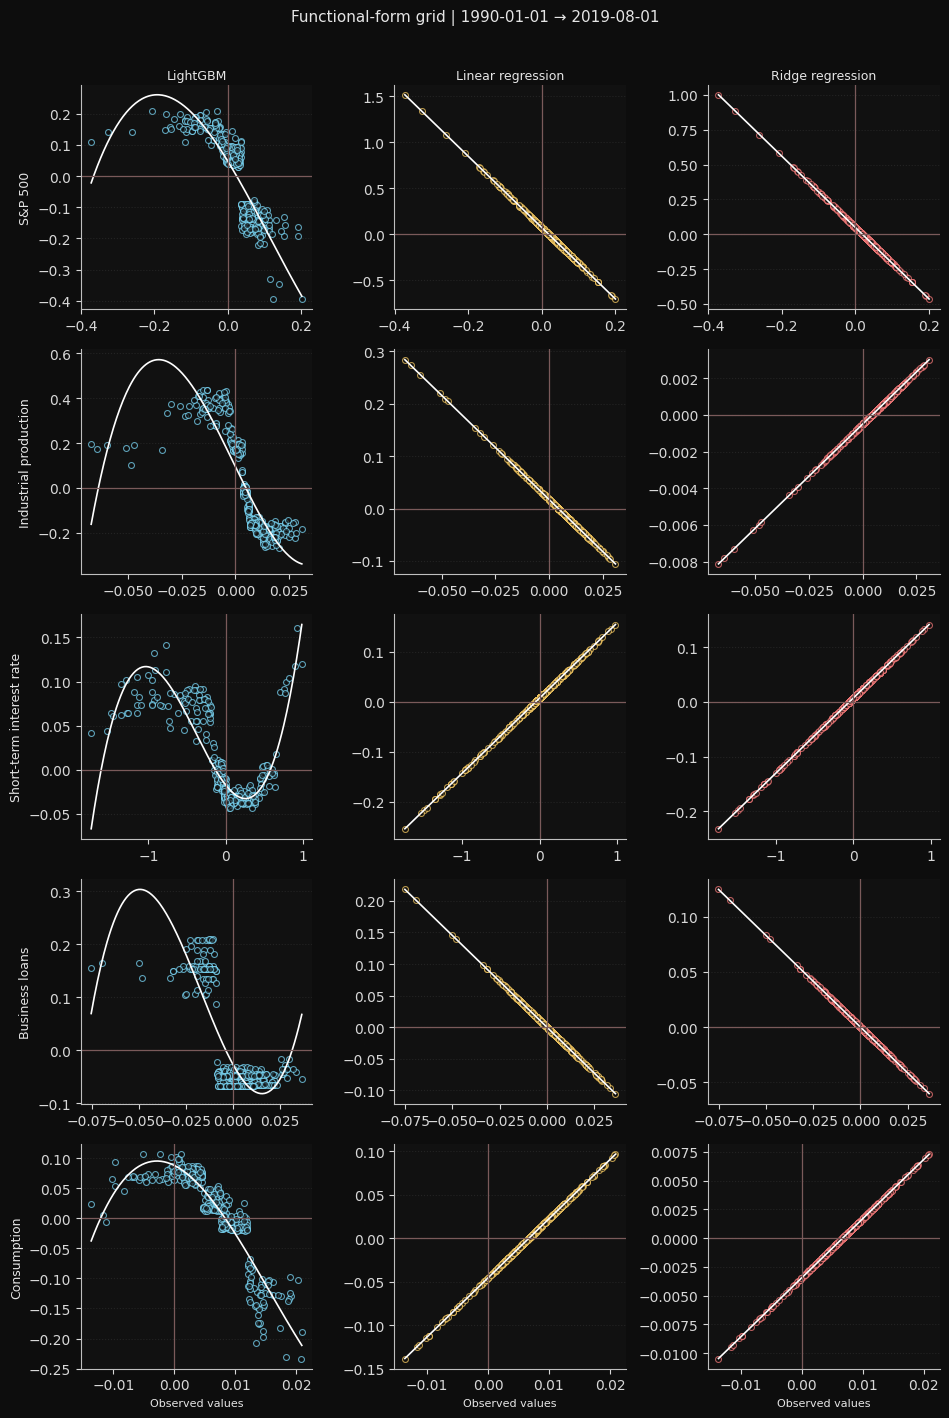

In [13]:
_pretty_label_from_feat = {
    "SP500_lag12": "S&P 500",
    "INDPRO_lag12": "Industrial production",
    "TB3MS_lag12": "Short-term interest rate",
    "BUSLOANS_lag12": "Business loans",
    "DPCERA3M086SBEA_lag12": "Consumption",
}

selected_vars = [
    "SP500_lag12",
    "INDPRO_lag12",
    "TB3MS_lag12",
    "BUSLOANS_lag12",
    "DPCERA3M086SBEA_lag12",
]

fig, axes = plot_functional_grid(
    models_dict=models_dict,
    X_dict=X_dict,
    selected_vars=selected_vars,
    start_date="1990-01-01",
    end_date="2019-08-01",
    date_col="ds",
    poly_deg_lgbm=3,
    figsize_per_cell=(3.2, 2.8),
    sharey=False,
    max_n=1500,
    random_state=42,
    _pretty_label_from_feat=_pretty_label_from_feat,
    use_pretty_labels=True,
)
plt.show()

La figure montre les formes fonctionnelles que LightGBM (modèle de Machine Learning) a apprises à partir des variables les plus importantes (cf commentaire). 

Elle représente les valeurs locales de Shapley en fonction des valeurs observées des variables explicatives (axe horizontal). Les lignes correspondent aux variables et les colonnes aux différents modèles. La forme fonctionnelle approximative apprise par chaque modèle pour chaque variable est tracée à l’aide d’un polynôme de degré trois ajusté aux données. 

Interprétation :
- Importance de 0 :
0 est le repère ultime de ce graphique. 
A l'intersection de 0, la variable ne contribue pas à la prévision du chômage. Ce qui est donc encourageant c'est qu'on a des nuages de points qui s'écartent tout le temps de 0.  

D'une manière générale, dans la zone à gauche et en haut, la variable diminue et le chômage est prévu à la hausse. Le contraire exact est à droite et en bas où la variable augmente avec une chômage dans un an diminué.  

- SP500
Les deux modèles linéaires ont ajusté une pente négative. Des valeurs boursiers plus élevés préparent à un taux de chômage plus faible un an plus tard. C'est très cohérent économiquement parlant. 

Le modèle LightGBM permet d’aller plus loin. Il montre que les fortes baisses du marché, comme lors de la crise financière de 2008 ou du choc Covid en 2020, sont associées à une forte hausse du chômage futur. Toutefois, on observe un effet de saturation : au-delà d’un certain niveau de chute du marché, des baisses supplémentaires du S&P 500 n’augmentent plus fortement le chômage.

- Industrial Production :
L'apport du Machine Learning est très visible ici. Il permet de trancher sur la confusion entre la Régression linéaire et Ridge. 

- Short-Terme Interest 
Les deux modèles linéaires ont trouvé une droite croissante. Si le taux augmente, le chômage l'est aussi. Dans la littérature économique, il peut y avoir plusieurs canaux de transmissions de cette politique monétaire. Mais ici, l'explication passe certainement via le crédit bancaire qui suit le même rythme. Si la Fed augmente son taux, le crédit bancaire est devenu plus cher. Puisque les banques primaires rehaussent aussi leur taux d'intérêt. çà impacte négativement l'investissement. Une hausse du cômage est donc attendu dans une année. Celà relève de la logique du modèle Keynésien IS-LM en science économique.

Le modèle LightGBM révèle toutefois une relation plus nuancée, qui reflète plusieurs épisodes de l’histoire économique américaine et différents canaux de transmission de la politique monétaire. Par exemple, lors des crises économiques comme celles de 1990, des subprimes en 2008 ou de Covid-19, la Fed a fortement baissé ses taux pour soutenir l’économie, alors que le chômage augmentait déjà. Cette politique vise à stimuler le crédit, l’investissement et la consommation afin de relancer l’activité.

À l’inverse, dans les années 1970, les chocs pétroliers ont fortement augmenté les coûts de production des entreprises. Cette hausse des coûts s’est traduite par une inflation élevée et un ralentissement de l’activité et du chômage. La Fed a alors relevé ses taux pour lutter contre l’inflation. Les entreprises ont pu souffler et ce qui a réduit le chômage. C'est ce qui a passé aussi durant les années 80 avec la politique monétaire de Paul Volcker entré dans l'histoire. 

- Consumption
Aux États-Unis, la consommation représente environ 70 % du PIB. Elle est donc le principal moteur de l’activité économique.

Quand la consommation augmente, la demande adressée aux entreprises augmente aussi. Les entreprises produisent davantage et embauchent plus, ce qui tend à réduire le chômage.

Cependant, les modèles linéaires (Linear et Ridge) suggèrent une relation positive entre consommation et chômage futur, ce qui peut sembler contre-intuitif. Le modèle LightGBM permet de lever ce doute en montrant qu’une faible consommation est associée à une hausse du chômage futur, tandis qu’une consommation élevée soutient l’emploi.